In [1]:
import mujoco as mj
import numpy as np

# Load the XML model
xml_path = "/home/zimengchai/Documents/IsaacLab/sim2real/xmls/scene_t1_ik.xml"
model = mj.MjModel.from_xml_path(xml_path)
data = mj.MjData(model)

# Set default pose (dimension 2-2+14 = 14)
default_qpos = np.array([
    0.2, -1.35, 0.0, -1.6, 0.0, 0.0, 0.0,
    0.2, 1.35, 0.0, 1.6, 0.0, 0.0, 0.0
])

# Set the joint positions (starting from index 2)
data.qpos[2:2+14] = default_qpos

# Forward kinematics to update the simulation state
mj.mj_forward(model, data)

print("Model loaded successfully!")
print(f"Number of joints: {model.nq}")
print(f"Number of sites: {model.nsite}")
print(f"\nJoint positions (qpos[2:16]): {data.qpos[2:2+14]}")

Model loaded successfully!
Number of joints: 29
Number of sites: 8

Joint positions (qpos[2:16]): [ 0.2  -1.35  0.   -1.6   0.    0.    0.    0.2   1.35  0.    1.6   0.
  0.    0.  ]


In [2]:
# Get site data
print("Site Information:")
print("=" * 60)

for i in range(model.nsite):
    site_name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_SITE, i)
    site_pos = data.site_xpos[i]
    site_mat = data.site_xmat[i].reshape(3, 3)
    
    print(f"\nSite {i}: {site_name}")
    print(f"  Position: {site_pos}")
    print(f"  Rotation matrix:\n{site_mat}")

# Print site positions in a compact format
print("\n" + "=" * 60)
print("Site Positions Summary:")
print("=" * 60)
for i in range(model.nsite):
    site_name = mj.mj_id2name(model, mj.mjtObj.mjOBJ_SITE, i)
    site_pos = data.site_xpos[i]
    print(f"{site_name:20s}: [{site_pos[0]:8.4f}, {site_pos[1]:8.4f}, {site_pos[2]:8.4f}]")

Site Information:

Site 0: world
  Position: [0. 0. 0.]
  Rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Site 1: imu
  Position: [0.   0.   0.66]
  Rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Site 2: head
  Position: [0.1425  0.      1.06485]
  Rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Site 3: left_hand
  Position: [0.37974555 0.19708654 0.62245447]
  Rotation matrix:
[[ 0.98515919 -0.16598723  0.04369902]
 [-0.00639628  0.21891326  0.97572336]
 [-0.17152391 -0.96152235  0.21460271]]

Site 4: right_hand
  Position: [ 0.37974555 -0.19708654  0.62245447]
  Rotation matrix:
[[ 0.98515919  0.16598723  0.04369902]
 [ 0.00639628  0.21891326 -0.97572336]
 [-0.17152391  0.96152235  0.21460271]]

Site 5: trunk
  Position: [0.0625 0.     0.5445]
  Rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Site 6: left_foot
  Position: [0.0485   0.10625  0.016646]
  Rotation matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Site 7: right_foot
  Position: [ 0.0485   -0.1062

In [3]:
# Get site positions and orientations in IMU frame
import mujoco as mj
from scipy.spatial.transform import Rotation as R

# Get IMU (torso) frame
imu_site_id = mj.mj_name2id(model, mj.mjtObj.mjOBJ_SITE, "imu")
imu_pos = data.site_xpos[imu_site_id]
imu_mat = data.site_xmat[imu_site_id].reshape(3, 3)

# Sites of interest
sites_of_interest = ["left_hand", "right_hand", "left_foot", "right_foot"]

print("Site Positions and Orientations in IMU Frame:")
print("=" * 80)

site_data_in_imu = {}

for site_name in sites_of_interest:
    try:
        site_id = mj.mj_name2id(model, mj.mjtObj.mjOBJ_SITE, site_name)
        
        # Get site position and rotation in world frame
        site_pos_world = data.site_xpos[site_id]
        site_mat_world = data.site_xmat[site_id].reshape(3, 3)
        
        # Transform position to IMU frame
        # pos_imu = R_imu^T @ (pos_world - imu_pos)
        pos_in_imu = imu_mat.T @ (site_pos_world - imu_pos)
        
        # Transform orientation to IMU frame
        # R_site_in_imu = R_imu^T @ R_site_world
        rot_in_imu = imu_mat.T @ site_mat_world
        
        # Convert rotation matrix to quaternion (w, x, y, z)
        quat_in_imu = R.from_matrix(rot_in_imu).as_quat()  # Returns [x, y, z, w]
        quat_wxyz = np.array([quat_in_imu[3], quat_in_imu[0], quat_in_imu[1], quat_in_imu[2]])
        
        # Convert to Euler angles (roll, pitch, yaw) for easier interpretation
        euler_in_imu = R.from_matrix(rot_in_imu).as_euler('xyz', degrees=True)
        
        site_data_in_imu[site_name] = {
            'position': pos_in_imu,
            'quaternion': quat_wxyz,
            'euler': euler_in_imu
        }
        
        print(f"\n{site_name.upper()}:")
        print(f"  Position (x, y, z):        [{pos_in_imu[0]:8.4f}, {pos_in_imu[1]:8.4f}, {pos_in_imu[2]:8.4f}]")
        print(f"  Quaternion (w, x, y, z):   [{quat_wxyz[0]:8.4f}, {quat_wxyz[1]:8.4f}, {quat_wxyz[2]:8.4f}, {quat_wxyz[3]:8.4f}]")
        print(f"  Euler (r, p, y) [deg]:     [{euler_in_imu[0]:8.2f}, {euler_in_imu[1]:8.2f}, {euler_in_imu[2]:8.2f}]")
        
    except Exception as e:
        print(f"\n{site_name}: Not found or error - {e}")

print("\n" + "=" * 80)

Site Positions and Orientations in IMU Frame:

LEFT_HAND:
  Position (x, y, z):        [  0.3797,   0.1971,  -0.0375]
  Quaternion (w, x, y, z):   [  0.7776,  -0.6228,   0.0692,   0.0513]
  Euler (r, p, y) [deg]:     [  -77.42,     9.88,    -0.37]

RIGHT_HAND:
  Position (x, y, z):        [  0.3797,  -0.1971,  -0.0375]
  Quaternion (w, x, y, z):   [  0.7776,   0.6228,   0.0692,  -0.0513]
  Euler (r, p, y) [deg]:     [   77.42,     9.88,     0.37]

LEFT_FOOT:
  Position (x, y, z):        [  0.0485,   0.1062,  -0.6434]
  Quaternion (w, x, y, z):   [  1.0000,   0.0000,   0.0000,   0.0000]
  Euler (r, p, y) [deg]:     [    0.00,     0.00,     0.00]

RIGHT_FOOT:
  Position (x, y, z):        [  0.0485,  -0.1062,  -0.6434]
  Quaternion (w, x, y, z):   [  1.0000,   0.0000,   0.0000,   0.0000]
  Euler (r, p, y) [deg]:     [    0.00,     0.00,     0.00]



In [5]:
# Convert quaternions to rotation matrices and extract first 2 columns (6 values)
print("\nRotation Matrices (First 2 Columns as 6 values):")
print("=" * 80)

for site_name in sites_of_interest:
    try:
        quat_wxyz = site_data_in_imu[site_name]['quaternion']
        
        # Convert to rotation matrix
        # scipy uses [x, y, z, w] format
        quat_xyzw = np.array([quat_wxyz[1], quat_wxyz[2], quat_wxyz[3], quat_wxyz[0]])
        rot_mat = R.from_quat(quat_xyzw).as_matrix()
        
        # Extract first 2 columns (column-major order, flattened)
        col1 = rot_mat[:, 0]  # First column [r00, r10, r20]
        col2 = rot_mat[:, 1]  # Second column [r01, r11, r21]
        
        # Flatten to 6 values [r00, r10, r20, r01, r11, r21]
        rot_6d = np.concatenate([col1, col2])
        
        print(f"\n{site_name.upper()}:")
        print(f"  Full rotation matrix:")
        print(f"    {rot_mat.reshape(-1)}")
        print(f"  First 2 columns (6 values): [{rot_6d[0]:8.4f}, {rot_6d[1]:8.4f}, {rot_6d[2]:8.4f}, {rot_6d[3]:8.4f}, {rot_6d[4]:8.4f}, {rot_6d[5]:8.4f}]")
        
        # Store for later use
        site_data_in_imu[site_name]['rot_6d'] = rot_6d
        
    except Exception as e:
        print(f"\n{site_name}: Error - {e}")

print("\n" + "=" * 80)


Rotation Matrices (First 2 Columns as 6 values):

LEFT_HAND:
  Full rotation matrix:
    [ 0.98515919 -0.16598723  0.04369902 -0.00639628  0.21891326  0.97572336
 -0.17152391 -0.96152235  0.21460271]
  First 2 columns (6 values): [  0.9852,  -0.0064,  -0.1715,  -0.1660,   0.2189,  -0.9615]

RIGHT_HAND:
  Full rotation matrix:
    [ 0.98515919  0.16598723  0.04369902  0.00639628  0.21891326 -0.97572336
 -0.17152391  0.96152235  0.21460271]
  First 2 columns (6 values): [  0.9852,   0.0064,  -0.1715,   0.1660,   0.2189,   0.9615]

LEFT_FOOT:
  Full rotation matrix:
    [1. 0. 0. 0. 1. 0. 0. 0. 1.]
  First 2 columns (6 values): [  1.0000,   0.0000,   0.0000,   0.0000,   1.0000,   0.0000]

RIGHT_FOOT:
  Full rotation matrix:
    [1. 0. 0. 0. 1. 0. 0. 0. 1.]
  First 2 columns (6 values): [  1.0000,   0.0000,   0.0000,   0.0000,   1.0000,   0.0000]



In [15]:
# Print formatted tensors for Python code
print("\nFormatted Tensors for Python Code:")
print("=" * 80)

# Body order: left_hand, right_hand, left_foot, right_foot
body_order = ["left_hand", "right_hand", "left_foot", "right_foot"]

print("\n# Body order: [left_hand, right_hand, left_foot, right_foot]")
print("self.default_local_body_pos = torch.tensor([")
for body_name in body_order:
    pos = site_data_in_imu[body_name]['position']
    print(f"    [{pos[0]:7.4f}, {pos[1]:7.4f}, {pos[2]:7.4f}],   # {body_name.replace('_', ' ').title()} position in IMU frame")
print("])")

print("\n# Rotation matrices (first 2 columns, 6 values per body)")
print("# Format: [col1_x, col1_y, col1_z, col2_x, col2_y, col2_z]")
print("self.default_local_body_rot = torch.tensor([")
for body_name in body_order:
    rot_6d = site_data_in_imu[body_name]['rot_6d']
    quat = site_data_in_imu[body_name]['quaternion']
    print(f"    [{rot_6d[0]:7.4f}, {rot_6d[1]:7.4f}, {rot_6d[2]:7.4f}, {rot_6d[3]:7.4f}, {rot_6d[4]:7.4f}, {rot_6d[5]:7.4f}],   # {body_name.replace('_', ' ').title()}")
print("])")

print("\n" + "=" * 80)


Formatted Tensors for Python Code:

# Body order: [left_hand, right_hand, left_foot, right_foot]
self.default_local_body_pos = torch.tensor([
    [ 0.3797,  0.1971, -0.0375],   # Left Hand position in IMU frame
    [ 0.3797, -0.1971, -0.0375],   # Right Hand position in IMU frame
    [ 0.0485,  0.1062, -0.6434],   # Left Foot position in IMU frame
    [ 0.0485, -0.1062, -0.6434],   # Right Foot position in IMU frame
])

# Rotation matrices (first 2 columns, 6 values per body)
# Format: [col1_x, col1_y, col1_z, col2_x, col2_y, col2_z]
self.default_local_body_rot = torch.tensor([
    [ 0.9852, -0.0064, -0.1715, -0.1660,  0.2189, -0.9615],   # Left Hand
    [ 0.9852,  0.0064, -0.1715,  0.1660,  0.2189,  0.9615],   # Right Hand
    [ 1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],   # Left Foot
    [ 1.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000],   # Right Foot
])



In [16]:
# Visualize the robot pose
import mujoco.viewer as viewer
import time

# Option 1: Interactive viewer (launches a GUI window)
print("Launching interactive viewer...")
print("Close the viewer window to continue execution.")
print("=" * 80)

with viewer.launch_passive(model, data) as v:
    # Keep the viewer open for 10 seconds or until manually closed
    start_time = time.time()
    while v.is_running() and (time.time() - start_time) < 30:
        # Update the viewer
        mj.mj_forward(model, data)
        v.sync()
        time.sleep(0.01)

print("\nViewer closed.")

Launching interactive viewer...
Close the viewer window to continue execution.

Viewer closed.


AttributeError: 'Renderer' object has no attribute 'camera'

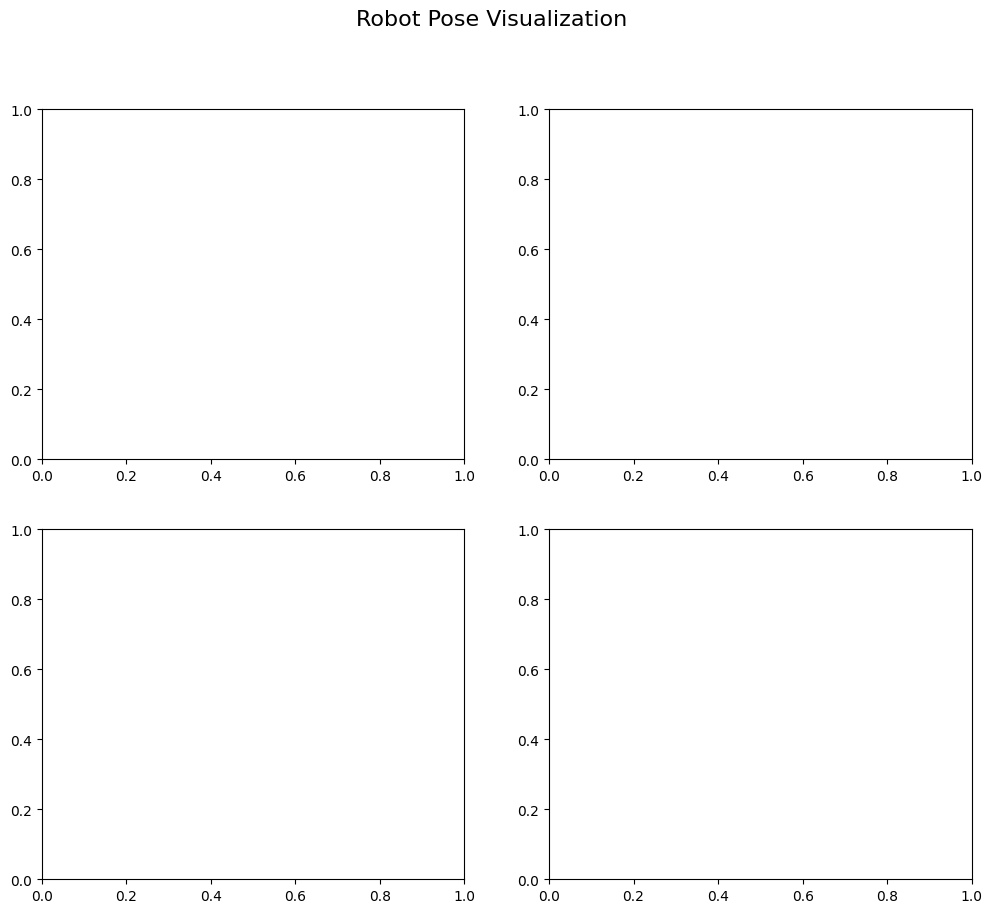

In [17]:
# Option 2: Render to image (for notebook display)
import matplotlib.pyplot as plt
from PIL import Image

# Create renderer
renderer = mj.Renderer(model, height=480, width=640)

# Update the scene
renderer.update_scene(data)

# Render from different viewpoints
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Robot Pose Visualization', fontsize=16)

# Camera settings for different views
views = [
    {"azimuth": 90, "elevation": -20, "distance": 3.0, "lookat": [0, 0, 1]},   # Front view
    {"azimuth": 0, "elevation": -20, "distance": 3.0, "lookat": [0, 0, 1]},    # Side view
    {"azimuth": 180, "elevation": -20, "distance": 3.0, "lookat": [0, 0, 1]},  # Back view
    {"azimuth": 45, "elevation": -30, "distance": 3.5, "lookat": [0, 0, 1]},   # Isometric view
]

view_names = ["Front View", "Side View (Right)", "Back View", "Isometric View"]

for idx, (ax, view, name) in enumerate(zip(axes.flatten(), views, view_names)):
    # Set camera
    renderer.camera.azimuth = view["azimuth"]
    renderer.camera.elevation = view["elevation"]
    renderer.camera.distance = view["distance"]
    renderer.camera.lookat = view["lookat"]
    
    # Render
    renderer.update_scene(data)
    pixels = renderer.render()
    
    # Display
    ax.imshow(pixels)
    ax.set_title(name)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Rendered robot pose from multiple viewpoints.")